## PtyChee Iterative Ptychography Demo

Running multi-slice LSQML and ePIE ptychography

Author: Zeyu Wang <br>
October 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PtyChee.preProcessing import realSpace_bin
from PtyChee import run

4D-STEM data and parameters read in.<br>
Data (from https://doi.org/10.1038/s41586-025-09693-6) are provided as .zip file in the 'data' folder and need to be unzipped into .npy files before running.

In [2]:
folder_path = 'data/'
file = 'MAPbI3_HT200_a13_ss0.3_31_F3sum.npy'
data_4D = np.load(folder_path+file)
print(data_4D.shape)

Voltage = 200               # keV, accelerate votage
alpha = 0.013               # rad, semi convergence angle
scan_step = 0.3             # Å,   scan step size

defocus = -60               # Å,   defocus

(800, 800, 38, 38)


This dataset was acquired with a total dose of only ~36 e<sup>-</sup>/Å<sup>2</sup>. By plotting a single CBED pattern, we can see just how sparse the signal is.

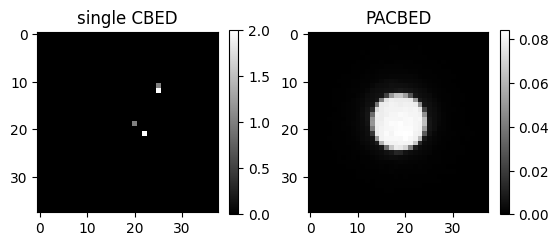

In [3]:
plt.subplot(121)
plt.imshow(data_4D[400,400], cmap='gray')
plt.title('single CBED')
plt.colorbar(shrink=0.5)
plt.subplot(122)
plt.imshow(np.mean(data_4D,axis=(0,1)), cmap='gray')
plt.title('PACBED')
plt.colorbar(shrink=0.5)
plt.show()

Simple preprocessing like cropping, binning and padding

In [4]:
data_4D = data_4D[-400:,-800:-400,:,:]
data_4D, scan_step = realSpace_bin(data_4D, scan_step, bin_factor=2)

real space bin 2 finished in 0.1818246841430664 s
data shape from (400, 400, 38, 38) to (200, 200, 38, 38)


A data of (800×800×38×38) is processed into (200×200×38×38) to simplify the demo

You can use PtyChee.finRotate to calculate the optimized scan rotate angle, <br>
see 'run_ptyChee_01_findRotate_and_iCoM_MAPbI3_F3sum.ipynb'

In [5]:
scan_rotation_angle = -176   # degrees
scan_flip = False            # flip X axis or not

Run mix-state multi-slice LSQML.


LSQML

File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
Voltage: 200 kV
Alpha: 0.013 rad
scan step: 0.6 Å/pixel
defocus: -60 Å
scan rotation angle: -176 degrees
scan flip x: False

#################### Data Information ####################
data shape: (200, 200, 38, 38)
data type: int32
CBED intensity range: 0 – 14
average CBED intensity: 38.188724517822266
BF center_Y: 18.574074074074073
BF center_X: 18.675925925925927
BF threshold: 0.5
Aperture Radius: 5.775335216480246 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.08975319633381454 1/Å/pixel
real space pixel size: 0.2932016969714284 Å/pixel
ptycho move: 2.0463728764109717 pixels

############### Probe Mixstates Parameters ###############
Probe States: 2
Probe Generation Mode: Hermite
Probe Radius: 4.47213595499958 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 6
recovered objFunc shape: (6, 493

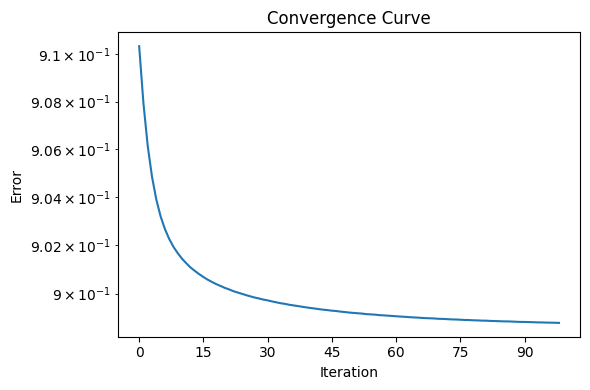

Object saving


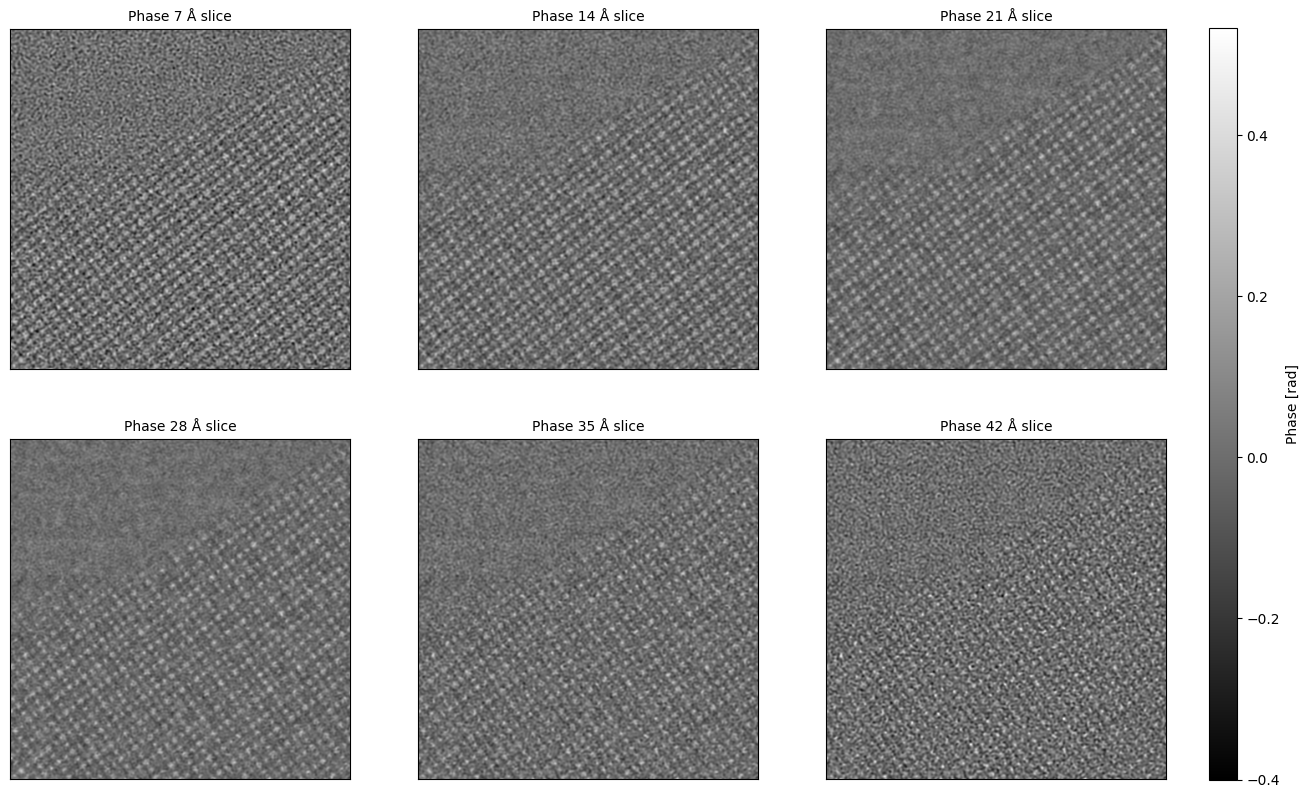

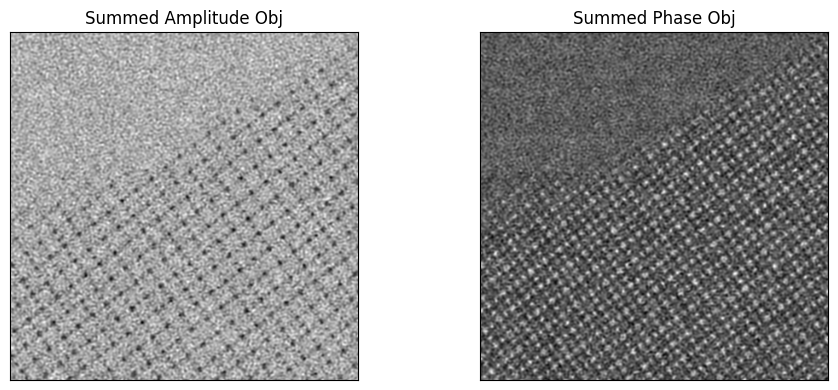

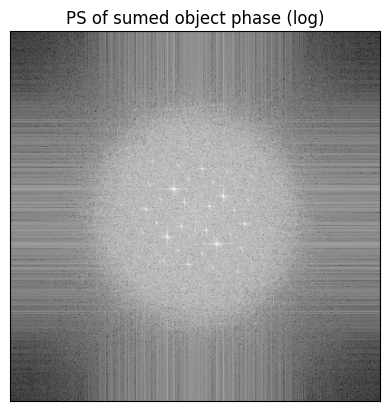

Probe saving


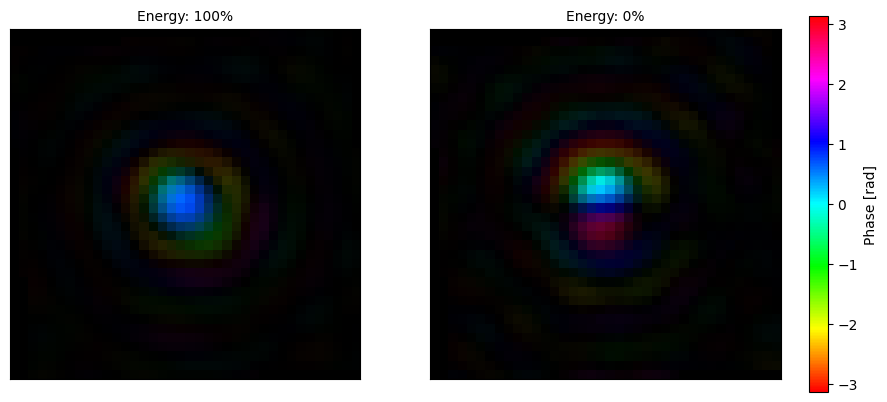

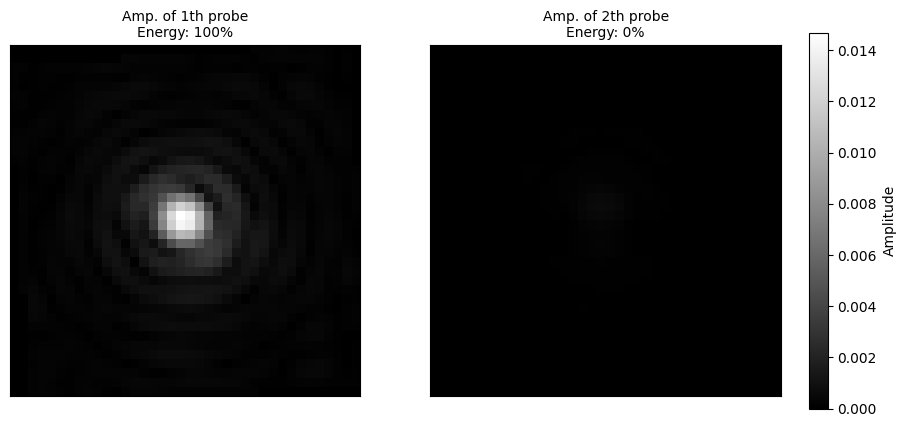

In [6]:
# LSQML
run.run_LSQML(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        n_state = 2,                   # probe states number
        n_slice = 6,                   # object slices number
        slice_thickness = 7,           # object slice thickness in Å
        iter_max = 100,                # maximum iteration numner
        s_O = 0.5,                     # step size for updating Object Function
        s_P = 0.1,                     # step size for updating Probe Function
        n_block = 60,                  # block number：The CBEDs are divided into n_block blocks for batch computing 
        position_clustering = True,    # cluster spatially adjacent scan positions; otherwise, positions are randomly assigned
        l1_fft_softThreshold = 0.3,    # soft threshold to constrain the sparsity of the reciprocal space
        device = "cuda:0",             # specify the GPU device or use "cpu"
        save_results = False,          # set 'True' to save the results
)

Run mix-state multi-slice ePIE. This is a blockwise implementation of ePIE, enabling ePIE to run faster than LSQML.


ePIE

File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
Voltage: 200 kV
Alpha: 0.013 rad
scan step: 0.6 Å/pixel
defocus: -60 Å
scan rotation angle: -176 degrees
scan flip x: False

#################### Data Information ####################
data shape: (200, 200, 38, 38)
data type: int32
CBED intensity range: 0 – 14
average CBED intensity: 38.188724517822266
BF center_Y: 18.574074074074073
BF center_X: 18.675925925925927
BF threshold: 0.5
Aperture Radius: 5.775335216480246 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.08975319633381454 1/Å/pixel
real space pixel size: 0.2932016969714284 Å/pixel
ptycho move: 2.0463728764109717 pixels

############### Probe Mixstates Parameters ###############
Probe States: 2
Probe Generation Mode: Hermite
Probe Radius: 4.47213595499958 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 6
recovered objFunc shape: (6, 493,

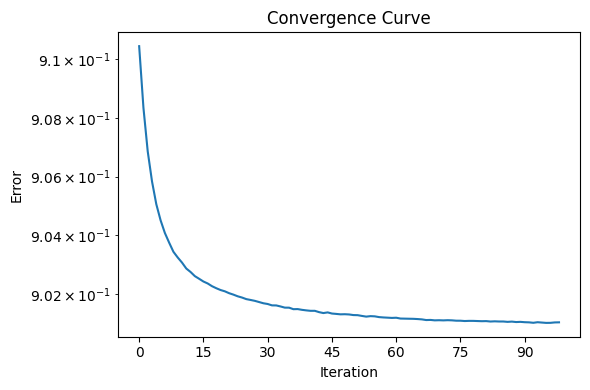

Object saving


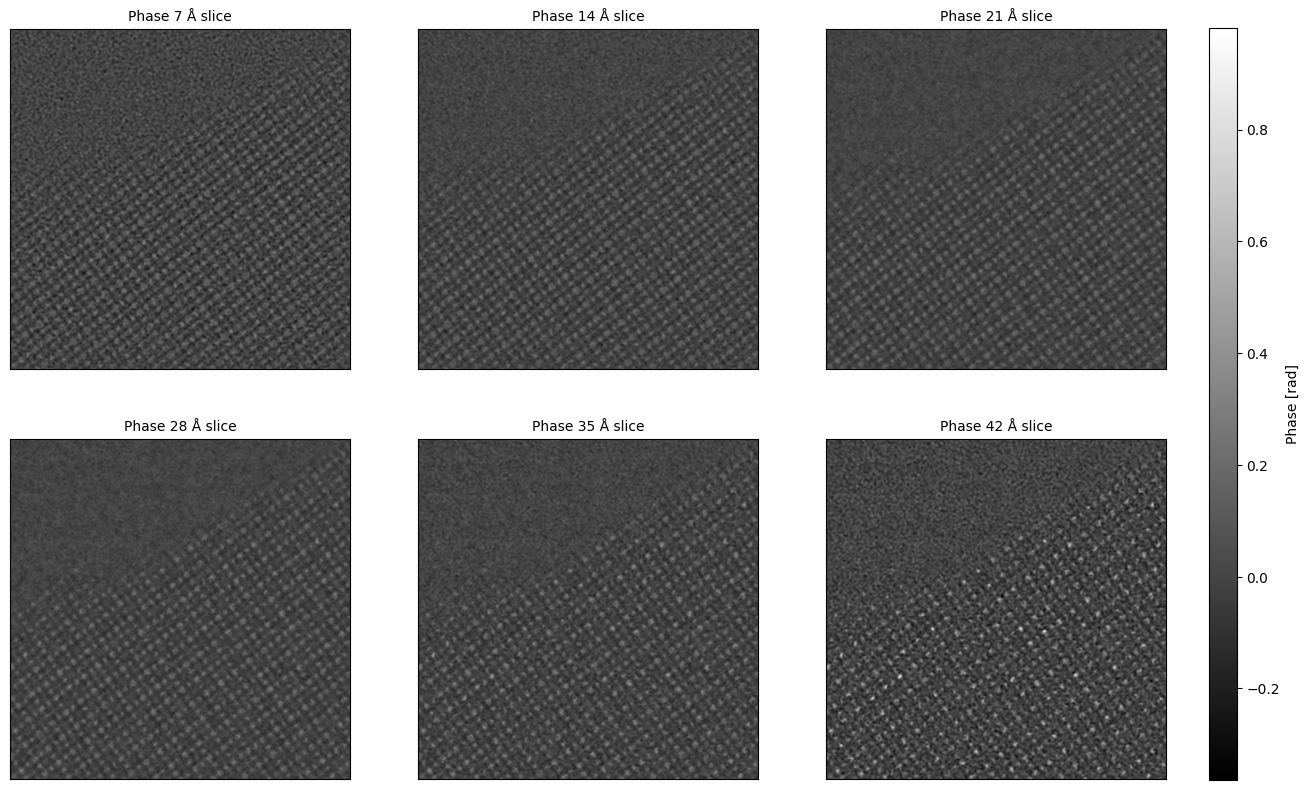

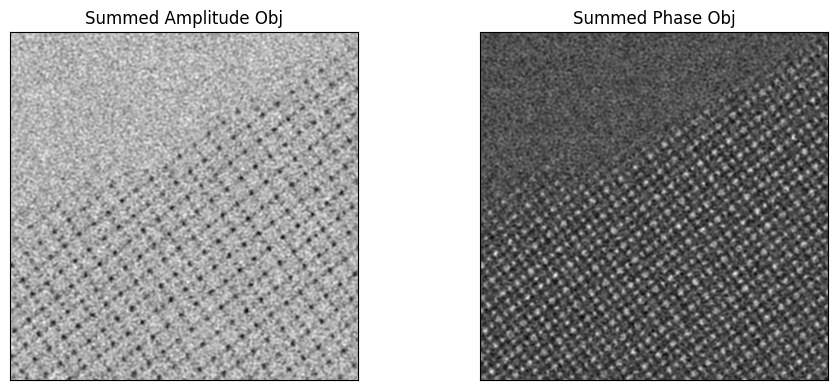

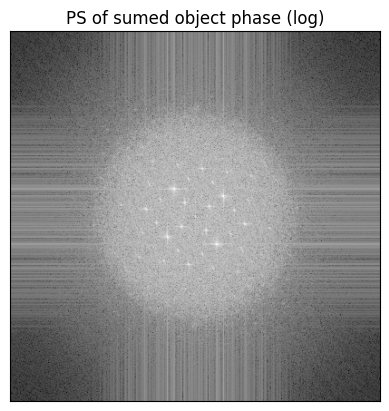

Probe saving


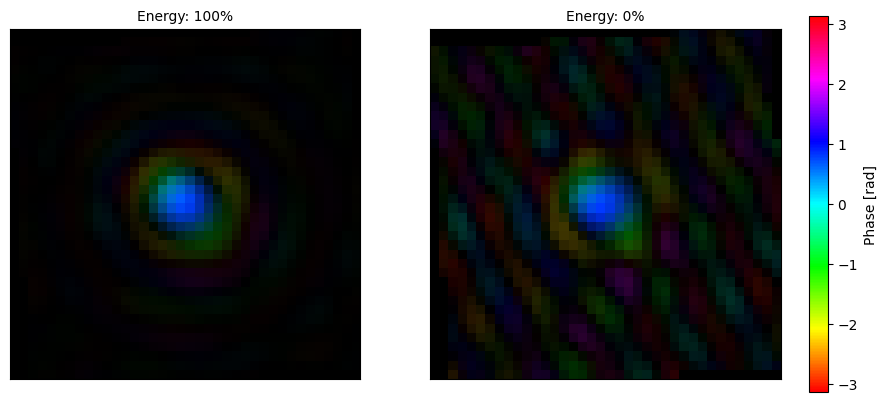

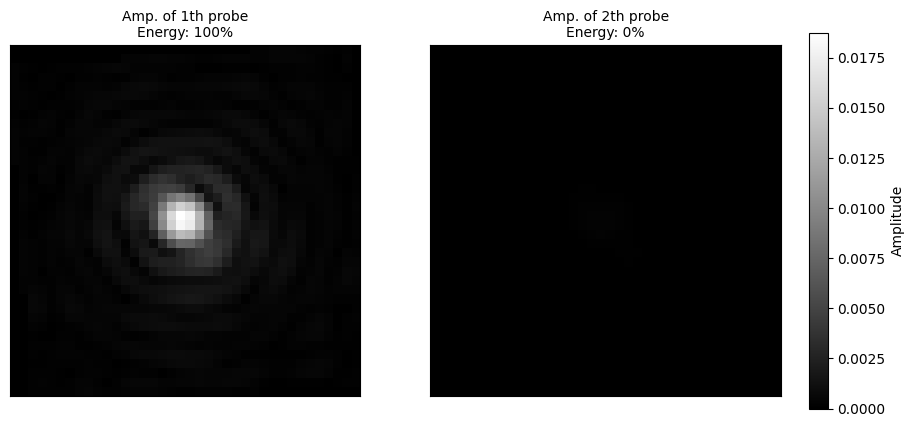

In [7]:
# ePIE
run.run_ePIE(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus = -60,
        n_state = 2,                   # probe states number
        n_slice = 6,                   # object slices number
        slice_thickness = 7,           # object slice thickness in Å
        iter_max = 100,                # maximum iteration numner
        s_O = 10,                      # step size for updating Object Function
        s_P = 1,                       # step size for updating Probe Function
        n_block = 60,                  # block number：The CBEDs are divided into n_block blocks for batch computing    
        l1_fft_softThreshold = 0.3,    # soft threshold to constrain the sparsity of the reciprocal space
        device = "cuda:0",             # specify the GPU device or use "cpu"
        save_results = False,          # set 'True' to save the results
)